In [ ]:
!pip install scikit-learn imblearn xgboost pandas matplotlib seaborn statsmodels 


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import sys
sys.path.append('/kaggle/input/datasets/eumubyey/pond-dataset/')
data_dir       = '/kaggle/input/datasets/eumubyey/pond-dataset/diabetes/diabetes/POND_data/'
ei_results_dir = '/kaggle/input/datasets/eumubyey/pond-dataset/diabetes/diabetes/results/'
ei_models_dir  = '/kaggle/input/datasets/eumubyey/pond-dataset/diabetes/diabetes/'

In [3]:
import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn utilities
from sklearn import metrics
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler

# Class imbalance
from imblearn.under_sampling import RandomUnderSampler

# Statistical testing
from scipy.stats import ranksums
from statsmodels.stats.multitest import fdrcorrection

from utils import fmeasure_score
import torch


print('All imports successful.')

All imports successful.


In [4]:
import huggingface_hub
huggingface_hub.login()

ImportError: The `notebook_login` function can only be used in a notebook (Jupyter or Colab) and you need the `ipywidgets` module: `pip install ipywidgets`.

In [ ]:
data_dir = '/kaggle/input/datasets/eumubyey/pond-dataset/diabetes/diabetes/POND_data/' 

# Data dictionary drives imputation type and modality assignment downsItream
data_dict = pd.read_csv(data_dir + 'data_dictionary.csv')

# Main feature table
nhanes_data = pd.read_csv(data_dir + 'Pond_bivariate.csv')

# These three variables are excluded from modelling.
# bmipct is retained separately for the ADA/AAP rule evaluation below.
exclude_vars = ['bmipct', 'INDFMPIR', 'SDDSRVYR']

nhanes_index = nhanes_data['SEQN'].values

# Merge preDM2 labels from the cohort file
preDM2_status = pd.read_csv(data_dir + 'Pond_9918_cohortAll.csv')
preDM2_status = preDM2_status[['SEQN', 'preDM2']]
preDM2_status = preDM2_status[preDM2_status['SEQN'].isin(nhanes_index)]

preDM2_y = nhanes_data.merge(
    preDM2_status, on='SEQN', how='left'
)['preDM2'].values.astype(int)

# Drop label and ID columns — features only from here on
nhanes_data.drop(columns=['preDM2', 'SEQN'] + exclude_vars, inplace=True, errors='ignore')

# ---- ADA/AAP clinical guideline (reference baseline) ----
# A child is flagged if BMI ≥ 85th percentile AND at least one additional risk factor.
# This is a hard binary rule it does not produce probabilities.
predm_ada = pd.read_csv(os.path.join(data_dir, 'Pond_aap.csv'))
predm_ada['ada'] = (
    (predm_ada['bmipct'] >= 85) &
    (predm_ada['HbpAAP'] | predm_ada['ChlAAP'] | predm_ada['raceAAP'])
).astype(float)

intersect_set = set(predm_ada['SEQN']).intersection(set(nhanes_index))
predm_ada_intersects = predm_ada[predm_ada['SEQN'].isin(intersect_set)]
predm_ada_intersects = predm_ada_intersects.merge(preDM2_status, on='SEQN', how='left')

print(f'Feature matrix : {nhanes_data.shape}')
print(f'Label counts   : {pd.Series(preDM2_y).value_counts().to_dict()}  (0=no preDM2, 1=preDM2)')
print(f'Class imbalance ratio: {preDM2_y.sum() / len(preDM2_y):.2%} positive')

Feature matrix : (15149, 95)
Label counts   : {0: 13139, 1: 2010}  (0=no preDM2, 1=preDM2)
Class imbalance ratio: 13.27% positive


In [ ]:
modalities = data_dict['Domain'].dropna().unique().tolist()
modalities_mapping = {}   # will hold one DataFrame per domain
columns_na_mapping = {}   # stores fill values (useful for inference later)

# ---- Step 1: Imputation ----
# Fill missing values based on the variable type recorded in the data dictionary.
# This is done BEFORE encoding so mode/median is computed on the raw values.
for c in nhanes_data.columns:
    col_type = data_dict.loc[data_dict['VariableNameNHANES'] == c, 'Type'].values
    if len(col_type) == 0:
        val = nhanes_data[c].median()
    elif col_type[0] in ('Categorical', 'Binary'):
        val = nhanes_data[c].mode().values[0]
    else:  # Continuous or Ordinal
        val = nhanes_data[c].median()
    nhanes_data[c] = nhanes_data[c].fillna(val)
    columns_na_mapping[c] = val

# ---- Step 2: One-hot encoding, per modality ----
# Only categorical columns with >2 unique values are expanded.
# Binary columns are left as 0/1. Continuous/ordinal columns are left as-is.
data_dict_filtered = data_dict[~data_dict['VariableNameNHANES'].isin(exclude_vars)]

for m in modalities:
    col_names = data_dict_filtered.loc[
        data_dict_filtered['Domain'] == m, 'VariableNameNHANES'
    ].unique().tolist()
    dfs_ = []
    for c in col_names:
        col_type = data_dict_filtered.loc[
            data_dict_filtered['VariableNameNHANES'] == c, 'Type'
        ].values
        if len(col_type) > 0 and col_type[0] == 'Categorical' and nhanes_data[c].nunique() > 2:
            dfs_.append(pd.get_dummies(nhanes_data[c].astype(int), prefix=c))
        else:
            dfs_.append(nhanes_data[[c]])
    modalities_mapping[m] = pd.concat(dfs_, axis=1)

X_all = pd.concat(list(modalities_mapping.values()), axis=1)
feature_names = X_all.columns.tolist()

print(f'Full feature matrix (all modalities): {X_all.shape}')
for m, df in modalities_mapping.items():
    print(f'  {m}: {df.shape[1]} features')

Full feature matrix (all modalities): (15149, 108)
  Sociodemographic: 37 features
  Health status: 17 features
  Other lifestyle behaviors: 6 features
  Diet: 48 features


In [ ]:
def metrics_ADA(labels, predictions):
    """Evaluate a hard binary rule (e.g. ADA/AAP guideline).
    The threshold is implicit in the 0/1 predictions — no optimisation is applied.
    Used only for the clinical baseline.
    """
    perf_dict = {'metrics': [], 'scores': [], 'class': []}
    frp_pos = fmeasure_score(labels, predictions, pos_label=1)
    frp_neg = fmeasure_score(labels, predictions, thres=1 - frp_pos['thres'], pos_label=0)
    entries = [
        ('F-measure (pos)', frp_pos['F'], 'pos'),
        ('PPV',             frp_pos['P'], 'pos'),
        ('Sensitivity',     frp_pos['R'], 'pos'),
        ('F-measure (neg)', frp_neg['F'], 'neg'),
        ('NPV',             frp_neg['P'], 'neg'),
        ('Specificity',     frp_neg['R'], 'neg'),
        ('BalancedACC',     (frp_neg['R'] + frp_pos['R']) / 2, 'NA'),
        ('AUC',             metrics.roc_auc_score(labels, predictions), 'NA'),
    ]
    for name, score, cls in entries:
        perf_dict['metrics'].append(name)
        perf_dict['scores'].append(score)
        perf_dict['class'].append(cls)
    return pd.DataFrame(perf_dict)


def metrics_BA(labels, predictions):
    """Evaluate a probabilistic classifier.
    Sweeps the ROC curve to find the threshold maximising (sensitivity + specificity) / 2,
    then reports all metrics at that threshold.
    This is identical to notebook 1 — do not modify.
    """
    perf_dict = {'metrics': [], 'scores': [], 'class': []}
    fpr, tpr, thresholds = metrics.roc_curve(labels, predictions)
    specificity = 1 - fpr
    balance_accs = (specificity + tpr) / 2
    max_thres = thresholds[np.argmax(balance_accs)]

    frp_pos = fmeasure_score(labels, predictions, pos_label=1, thres=max_thres)
    frp_neg = fmeasure_score(labels, predictions, thres=1 - max_thres, pos_label=0)

    entries = [
        ('F-measure (pos)', frp_pos['F'], 'pos'),
        ('PPV',             frp_pos['P'], 'pos'),
        ('Sensitivity',     frp_pos['R'], 'pos'),
        ('F-measure (neg)', frp_neg['F'], 'neg'),
        ('NPV',             frp_neg['P'], 'neg'),
        ('Specificity',     frp_neg['R'], 'neg'),
        ('BalancedACC',     max(balance_accs), 'NA'),
        ('AUC',             metrics.roc_auc_score(labels, predictions), 'NA'),
    ]
    for name, score, cls in entries:
        perf_dict['metrics'].append(name)
        perf_dict['scores'].append(score)
        perf_dict['class'].append(cls)
    df = pd.DataFrame(perf_dict)
    df['optimize'] = 'BalanceAcc'
    return df


# Compute the ADA/AAP baseline scores now used as a reference line in plots
ada_scores = metrics_ADA(
    labels=predm_ada_intersects['preDM2'],
    predictions=predm_ada_intersects['ada']
)
ada_scores

,metrics,scores,class
0,F-measure (pos),0.255451,pos
1,PPV,0.177011,pos
2,Sensitivity,0.458730,pos
3,F-measure (neg),0.768123,neg
4,NPV,0.891101,neg
5,Specificity,0.674972,neg
6,BalancedACC,0.566851,NA
7,AUC,0.566851,NA


In [ ]:
X_np = X_all.values.astype(np.float32)
y_np = preDM2_y.astype(int)

# Feature selection
ei_imp = pd.read_csv(ei_results_dir + 'int.csv')
top_features = ei_imp['feature'].head(40).tolist()
X_filtered = X_all[[f for f in top_features if f in X_all.columns]]

# Override X_np with the filtered version
X_np = X_filtered.values.astype(np.float32)
feature_names = X_filtered.columns.tolist()

print(f'Original feature matrix: {X_all.shape}')
print(f'Filtered feature matrix: {X_np.shape}')

Original feature matrix: (15149, 108)
Filtered feature matrix: (15149, 30)


In [ ]:
import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

# Retrieve the secret you set
secret_client = UserSecretsClient()
hf_token = secret_client.get_secret("HF_TOKEN")

# Log in to Hugging Face
login(token=hf_token)
print("Successfully logged in with HF_TOKEN.")

Successfully logged in with HF_TOKEN.


In [ ]:
token = secret_client.get_secret("TABPFN_TOKEN")
os.environ["TABPFN_TOKEN"] = token
print(f"Token set: {os.environ.get('TABPFN_TOKEN', '')[:10]}...")

!pip install tabpfn -q

from tabpfn import TabPFNClassifier

tabpfn_results = []
random_seeds = random.sample(range(100), 10)

for idx, seed in enumerate(random_seeds):
    print(f'Seed {idx+1}/10 (seed={seed})')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    oof_probs  = np.zeros(len(y_np))
    oof_labels = np.zeros(len(y_np), dtype=int)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_np, y_np)):
        X_tr, y_tr   = X_np[train_idx], y_np[train_idx]
        X_val, y_val = X_np[val_idx],   y_np[val_idx]

        # TabPFN has a 10,000 sample training limit
        # If training fold exceeds this, undersample to fit within the limit
        if len(X_tr) > 10000:
            rus = RandomUnderSampler(random_state=seed)
            X_tr, y_tr = rus.fit_resample(X_tr, y_tr)

        # Scale within fold 
        scaler = StandardScaler()
        X_tr_sc  = scaler.fit_transform(X_tr).astype(np.float32)
        X_val_sc = scaler.transform(X_val).astype(np.float32)

        # No training loop, no hyperparameters — just fit and predict
        clf = TabPFNClassifier(device='cuda', n_estimators=32)
        clf.fit(X_tr_sc, y_tr)

        oof_probs[val_idx]  = clf.predict_proba(X_val_sc)[:, 1]
        oof_labels[val_idx] = y_val
        print(f'  fold {fold+1} done')

    df_seed = metrics_BA(oof_labels, oof_probs)
    df_seed['dummy']   = idx
    df_seed['dataset'] = 'TabPFN'
    tabpfn_results.append(df_seed)

    auc = df_seed.loc[df_seed['metrics'] == 'AUC', 'scores'].values[0]
    ba  = df_seed.loc[df_seed['metrics'] == 'BalancedACC', 'scores'].values[0]
    print(f'  → AUC={auc:.4f}  BalancedACC={ba:.4f}')

tabpfn_df = pd.concat(tabpfn_results, ignore_index=True)
print('\nTabPFN complete.')

Token set: eyJhbGciOi...
Seed 1/10 (seed=57)


tabpfn-v2.6-classifier-v2.6_default.ckpt:   0%|          | 0.00/43.0M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6834  BalancedACC=0.6354
Seed 2/10 (seed=83)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6874  BalancedACC=0.6379
Seed 3/10 (seed=68)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6791  BalancedACC=0.6318
Seed 4/10 (seed=23)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6809  BalancedACC=0.6382
Seed 5/10 (seed=18)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6808  BalancedACC=0.6359
Seed 6/10 (seed=67)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6840  BalancedACC=0.6408
Seed 7/10 (seed=39)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6817  BalancedACC=0.6365
Seed 8/10 (seed=36)
  fold 1 done
  fold 2 done
  fold 3 done
  fold 4 done
  fold 5 done
  → AUC=0.6855  BalancedACC=0.6383
Seed 9/10 (seed=79)


In [ ]:
# 1. Save the main results DataFrame
tabpfn_df.to_csv('tabpfn_results.csv', index=False)
print("✓ Saved tabpfn_results.csv")

# 2. Save the OOF predictions 
np.save('oof_probs.npy', oof_probs)
np.save('oof_labels.npy', oof_labels)
print("✓ Saved oof_probs.npy and oof_labels.npy")

# 3. Save the random seeds 
import json
with open('random_seeds.json', 'w') as f:
    json.dump(random_seeds, f)
print("✓ Saved random_seeds.json")

# 4. Save the feature matrix and labels
np.save('X_np.npy', X_np)
np.save('y_np.npy', y_np)
print("✓ Saved X_np.npy and y_np.npy")

# 5. Save feature names
with open('feature_names.txt', 'w') as f:
    f.write('\n'.join(feature_names))
print("✓ Saved feature_names.txt")

✓ Saved tabpfn_results.csv
✓ Saved oof_probs.npy and oof_labels.npy
✓ Saved random_seeds.json
✓ Saved X_np.npy and y_np.npy
✓ Saved feature_names.txt


In [ ]:
# Load the saved results
tabpfn_df = pd.read_csv('/kaggle/input/models/eumubyey/tabpfn/other/default/1/tabpfn_results.csv')
oof_probs = np.load('/kaggle/input/models/eumubyey/tabpfn/other/default/1/oof_probs.npy')
oof_labels = np.load('/kaggle/input/models/eumubyey/tabpfn/other/default/1/oof_labels.npy')
X_np = np.load('/kaggle/input/models/eumubyey/tabpfn/other/default/1/X_np.npy')
y_np = np.load('/kaggle/input/models/eumubyey/tabpfn/other/default/1/y_np.npy')

# Load feature names
with open('/kaggle/input/models/eumubyey/tabpfn/other/default/1/feature_names.txt', 'r') as f:
    feature_names = f.read().splitlines()

# Load random seeds
import json
with open('/kaggle/input/models/eumubyey/tabpfn/other/default/1/random_seeds.json', 'r') as f:
    random_seeds = json.load(f)

print("✓ All data loaded successfully!")
print(f"tabpfn_df shape: {tabpfn_df.shape}")
print(f"oof_probs shape: {oof_probs.shape}")
print(f"X_np shape: {X_np.shape}")

✓ All data loaded successfully!
tabpfn_df shape: (80, 6)
oof_probs shape: (15149,)
X_np shape: (15149, 30)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

# Re-load the raw data to get subgroup columns 
raw = pd.read_csv(data_dir + 'Pond_bivariate.csv')

# Align to the same rows used in modelling 
raw = raw[raw['SEQN'].isin(nhanes_index)].reset_index(drop=True)

# Map codes to readable labels 
race_map = {0: 'Hispanic', 1: 'Non-Hispanic White', 2: 'Non-Hispanic Black', 3: 'Other'}
raw['RaceEth'] = raw['RaceEth'].map(race_map).fillna('Unknown')

sex_map  = {1: 'Male', 2: 'Female'}
raw['RIAGENDR'] = raw['RIAGENDR'].map(sex_map).fillna('Unknown')

insurance_map  = {0:'Private insurance', 1:'Medicaid/CHIP', 2:'Other insurance',3: 'Not insured'}
raw['HIns4'] = raw['HIns4'].map(insurance_map).fillna('Unknown')

# Attach OOF predictions from the last TabPFN seed run 
# oof_probs and oof_labels are already defined from the training loop
raw['oof_prob']  = oof_probs
raw['oof_label'] = oof_labels


# Step 3: Subgroup evaluation function
def subgroup_fairness(df, group_col, prob_col='oof_prob', label_col='oof_label',
                      min_pos=20):
    """
    For each unique value of group_col, compute AUC and Balanced Accuracy.
    Skips groups with fewer than min_pos positive examples (AUC unstable).
    Returns a tidy DataFrame.
    """
    rows = []
    for grp_val, grp_df in df.groupby(group_col):
        y_true = grp_df[label_col].values
        y_prob = grp_df[prob_col].values

        n_pos = y_true.sum()
        n_neg = (1 - y_true).sum()

        if n_pos < min_pos or n_neg < min_pos:
            print(f'  Skipping {group_col}={grp_val}: '
                  f'only {n_pos} positives / {n_neg} negatives')
            continue

        # threshold at 0.5 for BA
        y_pred = (y_prob >= 0.5).astype(int)

        auc = roc_auc_score(y_true, y_prob)
        ba  = balanced_accuracy_score(y_true, y_pred)

        rows.append({
            'subgroup_col':   group_col,
            'subgroup_value': grp_val,
            'n_total':        len(grp_df),
            'n_pos':          int(n_pos),
            'prev_pct':       round(100 * n_pos / len(grp_df), 1),
            'AUC':            round(auc, 4),
            'BalancedAcc':    round(ba,  4),
        })

    return pd.DataFrame(rows)


# Run for each subgroup axis
results_race = subgroup_fairness(raw, 'RaceEth')
results_sex  = subgroup_fairness(raw, 'RIAGENDR')
results_ins  = subgroup_fairness(raw, 'HIns4')

fairness_df = pd.concat([results_race, results_sex, results_ins], ignore_index=True)
fairness_df.to_csv("fairness1.csv", index=False)
print(fairness_df.to_string(index=False))

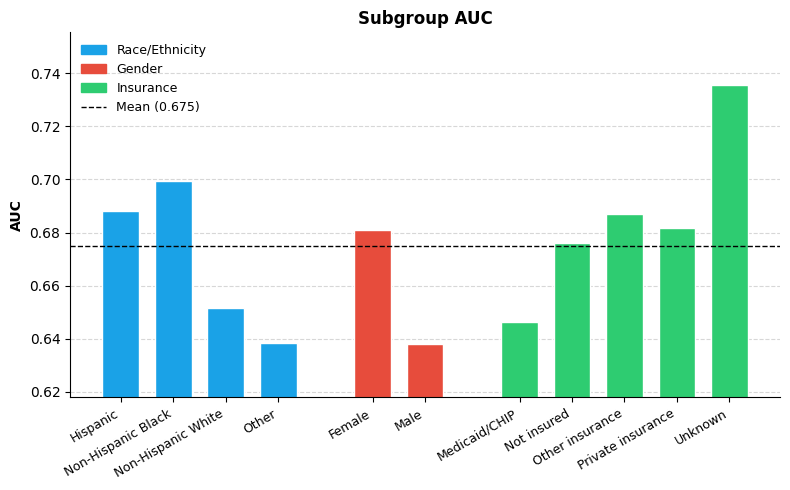

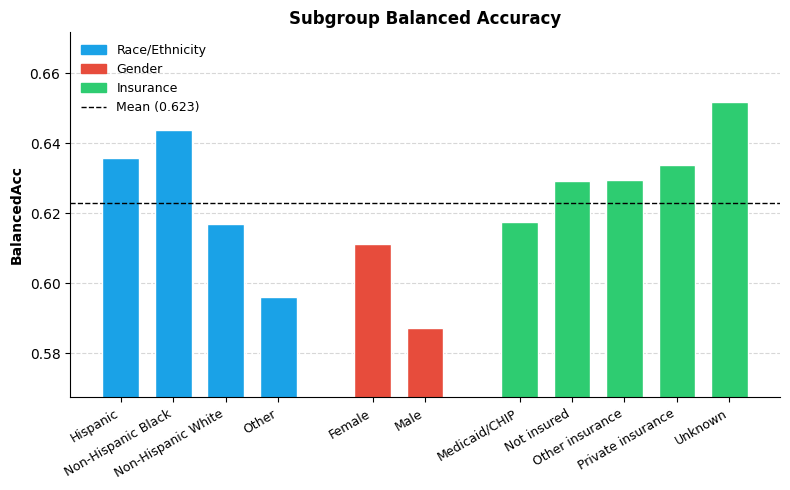

In [ ]:
feature_order  = ['RaceEth', 'RIAGENDR', 'HIns4']
feature_labels = {'RaceEth': 'Race/Ethnicity', 'RIAGENDR': 'Gender', 'HIns4': 'Insurance'}
colors         = {'RaceEth': '#1AA2E7', 'RIAGENDR': '#E74C3C', 'HIns4': '#2ECC71'}

for metric in ['AUC', 'BalancedAcc']:
    fig, ax = plt.subplots(figsize=(8, 5))
    x_pos = 0
    tick_positions, tick_labels = [], []
    legend_handles = []

    for feat in feature_order:
        grp_df = fairness_df[fairness_df['subgroup_col'] == feat]
        for _, row in grp_df.iterrows():
            ax.bar(x_pos, row[metric], color=colors[feat], edgecolor='white', width=0.7)
            tick_positions.append(x_pos)
            tick_labels.append(row['subgroup_value'])
            x_pos += 1
        legend_handles.append(
            plt.Rectangle((0, 0), 1, 1, color=colors[feat], label=feature_labels[feat])
        )
        x_pos += 0.8

    overall = fairness_df[metric].mean()
    legend_handles.append(
        plt.Line2D([0], [0], color='black', linestyle='--', linewidth=1, label=f'Mean ({overall:.3f})')
    )
    ax.axhline(overall, color='black', linestyle='--', linewidth=1)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontweight='bold')
    ax.set_title('Subgroup AUC' if metric == 'AUC' else 'Subgroup Balanced Accuracy', fontweight='bold')
    ax.set_ylim(fairness_df[metric].min() - 0.02, fairness_df[metric].max() + 0.02)
    ax.legend(handles=legend_handles, fontsize=9, frameon=False)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)

    plt.tight_layout()
    fname = 'fairness_AUC.png' if metric == 'AUC' else 'fairness_BalancedAcc.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
!pip install fairlearn

In [ ]:
from sklearn.metrics import confusion_matrix
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.metrics import equalized_odds_difference, MetricFrame

SENSITIVE_FEATURES = {
    'RaceEthnicity': 'RaceEth',
    'Gender':        'RIAGENDR',
    'Insurance':     'HIns4',
}
 
def equalized_odds_by_group(df, group_col, prob_col='oof_prob',
                             label_col='oof_label', threshold=0.5):
    """Compute TPR and FPR for each group in group_col."""
    rows = []
    for grp, grp_df in df.groupby(group_col):
        y_true = grp_df[label_col].values
        y_pred = (grp_df[prob_col].values >= threshold).astype(int)
 
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
 
        rows.append({
            'group':    grp,
            'n':        len(grp_df),
            'n_pos':    int(y_true.sum()),
            'TPR':      round(tpr, 4),
            'FPR':      round(fpr, 4),
        })
    return pd.DataFrame(rows)
 
 
print("=" * 60)
print("PRE-MITIGATION: TPR / FPR by subgroup")
print("=" * 60)
for label, col in SENSITIVE_FEATURES.items():
    print(f"\n── {label} ──")
    print(equalized_odds_by_group(raw, col).to_string(index=False))
 
 
print("\n" + "=" * 60)
print("EQUALIZED ODDS DIFFERENCE (pre-mitigation)")
print("0.0 = perfect fairness | higher = more disparity")
print("=" * 60)
 
y_true_all = raw['oof_label'].values
y_pred_all = (raw['oof_prob'].values >= 0.5).astype(int)
 
for label, col in SENSITIVE_FEATURES.items():
    eo = equalized_odds_difference(
        y_true_all, y_pred_all,
        sensitive_features=raw[col]
    )
    print(f"  {label:<20} EO Difference = {eo:.4f}")

PRE-MITIGATION: TPR / FPR by subgroup

── RaceEthnicity ──
             group    n  n_pos    TPR    FPR
          Hispanic 5565    711 0.6751 0.4034
Non-Hispanic Black 4292    676 0.7189 0.4314
Non-Hispanic White 4033    431 0.5499 0.3159
             Other 1259    192 0.6458 0.4536

── Gender ──
 group    n  n_pos    TPR    FPR
Female 7430    691 0.3893 0.1668
  Male 7719   1319 0.8021 0.6275

── Insurance ──
            group    n  n_pos    TPR    FPR
    Medicaid/CHIP 2026    268 0.6791 0.4443
      Not insured 2821    395 0.6709 0.4126
  Other insurance 3637    564 0.7447 0.4855
Private insurance 6392    744 0.5806 0.3132
          Unknown  273     39 0.7179 0.4145

EQUALIZED ODDS DIFFERENCE (pre-mitigation)
0.0 = perfect fairness | higher = more disparity
  RaceEthnicity        EO Difference = 0.1691
  Gender               EO Difference = 0.4607
  Insurance            EO Difference = 0.1723


In [23]:
from sklearn.base import BaseEstimator, ClassifierMixin

class PreFitClassifier(BaseEstimator, ClassifierMixin):
    """
    Wraps precomputed probabilities so ThresholdOptimizer
    can use them without refitting the model.
    """
    def fit(self, X, y):
        return self  

    def predict_proba(self, X):
        return np.column_stack([1 - oof_probs, oof_probs])

    def predict(self, X):
        return (oof_probs >= 0.5).astype(int)

In [26]:
base_clf = PreFitClassifier()
base_clf.fit(X_np, y_np)

mitigators = {}
fair_preds = {}

for label, col in SENSITIVE_FEATURES.items():
    sensitive = raw[col].values
    mitigator = ThresholdOptimizer(
        estimator=base_clf,
        constraints="equalized_odds",
        objective="balanced_accuracy_score",
        predict_method="predict_proba"
    )
    mitigator.fit(X_np, y_np, sensitive_features=sensitive)
    mitigators[label] = mitigator
    fair_preds[label] = mitigator.predict(X_np, sensitive_features=sensitive)

# ── Summary: Pre vs Post Mitigation ──────────────────────────────────────────
summary_rows = []
for label, col in SENSITIVE_FEATURES.items():
    y_pred_post = fair_preds[label]
    summary_rows.append({
        'Feature':      label,
        'EO (pre)':     round(equalized_odds_difference(y_true_all, y_pred_all,  sensitive_features=raw[col]), 4),
        'EO (post)':    round(equalized_odds_difference(y_true_all, y_pred_post, sensitive_features=raw[col]), 4),
        'BA (pre)':     round(balanced_accuracy_score(y_true_all, y_pred_all),   4),
        'BA (post)':    round(balanced_accuracy_score(y_true_all, y_pred_post),  4),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df['EO Δ']  = (summary_df['EO (post)'] - summary_df['EO (pre)']).round(4)
summary_df['BA Δ']  = (summary_df['BA (post)'] - summary_df['BA (pre)']).round(4)

print("\nFairness Mitigation Summary  (EO = Equalized Odds diff, BA = Balanced Accuracy)")
print(summary_df[['Feature', 'EO (pre)', 'EO (post)', 'EO Δ', 'BA (pre)', 'BA (post)', 'BA Δ']].to_string(index=False))

# ── Post-mitigation TPR / FPR by subgroup ────────────────────────────────────
print("\nPost-Mitigation TPR / FPR by Subgroup")
for label, col in SENSITIVE_FEATURES.items():
    temp = raw.copy()
    temp['fair_pred'] = fair_preds[label]
    tpr_fpr = equalized_odds_by_group(
        temp, col, prob_col='fair_pred', label_col='oof_label', threshold=0.5
    )
    print(f"\n  {label}")
    print(tpr_fpr.to_string(index=False))


Fairness Mitigation Summary  (EO = Equalized Odds diff, BA = Balanced Accuracy)
      Feature  EO (pre)  EO (post)    EO Δ  BA (pre)  BA (post)    BA Δ
RaceEthnicity    0.1691     0.0247 -0.1444    0.6345     0.6233 -0.0112
       Gender    0.4607     0.0051 -0.4556    0.6345     0.6060 -0.0285
    Insurance    0.1723     0.0540 -0.1183    0.6345     0.6208 -0.0137

Post-Mitigation TPR / FPR by Subgroup

  RaceEthnicity
             group    n  n_pos    TPR    FPR
          Hispanic 5565    711 0.5598 0.3201
Non-Hispanic Black 4292    676 0.5769 0.3125
Non-Hispanic White 4033    431 0.5522 0.3168
             Other 1259    192 0.5573 0.3196

  Gender
 group    n  n_pos    TPR    FPR
Female 7430    691 0.7033 0.4861
  Male 7719   1319 0.6983 0.4898

  Insurance
            group    n  n_pos    TPR    FPR
    Medicaid/CHIP 2026    268 0.6754 0.4329
      Not insured 2821    395 0.6886 0.4398
  Other insurance 3637    564 0.6684 0.4322
Private insurance 6392    744 0.6640 0.4253
        

In [28]:
# Pre vs Post AUC per sensitive feature
print("\nPre vs Post Mitigation AUC")

for label, col in SENSITIVE_FEATURES.items():
    y_pred_post = fair_preds[label]
    
    auc_pre  = roc_auc_score(y_true_all, y_pred_all)
    auc_post = roc_auc_score(y_true_all, y_pred_post)
    delta    = round(auc_post - auc_pre, 4)
    sign     = "+" if delta >= 0 else ""

    print(f"  {label:<20}  AUC pre={auc_pre:.4f}  post={auc_post:.4f}  Δ={sign}{delta}")


Pre vs Post Mitigation AUC
  RaceEthnicity         AUC pre=0.6345  post=0.6233  Δ=-0.0112
  Gender                AUC pre=0.6345  post=0.6060  Δ=-0.0285
  Insurance             AUC pre=0.6345  post=0.6208  Δ=-0.0137


In [50]:
from sklearn.metrics import roc_auc_score, balanced_accuracy_score

def get_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = metrics.confusion_matrix(y_true, y_pred).ravel()
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    ba  = balanced_accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    return tpr, fpr, ba, auc

def get_metrics_safe(y_true, y_pred, y_prob):
    if len(np.unique(y_true)) < 2 or y_true.sum() < 5:
        return None
    return get_metrics(y_true, y_pred, y_prob)

y_pred_pre = (y_pred_all >= 0.5).astype(int)

rows = []

for label, col in SENSITIVE_FEATURES.items():
    y_pred_post = fair_preds[label]
    y_prob_post = fair_probs.get(label, y_pred_post.astype(float))

    for grp_val, idx in raw.groupby(col).groups.items():
        mask = raw.index.isin(idx)

        pre_result  = get_metrics_safe(y_true_all[mask], y_pred_pre[mask],  y_pred_all[mask])
        post_result = get_metrics_safe(y_true_all[mask], y_pred_post[mask], y_prob_post[mask])

        if pre_result is None or post_result is None:
            print(f"  Skipping {label}={grp_val}: too few positive examples")
            continue

        tpr_pre,  fpr_pre,  ba_pre,  auc_pre  = pre_result
        tpr_post, fpr_post, ba_post, auc_post = post_result

        rows.append({
            'Feature':    label,
            'Subgroup':   grp_val,
            'TPR (pre)':  round(tpr_pre,  4),
            'TPR (post)': round(tpr_post, 4),
            'FPR (pre)':  round(fpr_pre,  4),
            'FPR (post)': round(fpr_post, 4),
            'BA (pre)':   round(ba_pre,   4),
            'BA (post)':  round(ba_post,  4),
            'AUC (pre)':  round(auc_pre,  4),
            'AUC (post)': round(auc_post, 4),
        })

results_df = pd.DataFrame(rows)

print("\nPre vs Post Mitigation — Metrics by Subgroup")
print("(TPR=sensitivity, FPR=1-specificity, BA=balanced accuracy, AUC)\n")
print(results_df.to_string(index=False))
results_df.to_csv("equalized_odds.csv", index=False)


Pre vs Post Mitigation — Metrics by Subgroup
(TPR=sensitivity, FPR=1-specificity, BA=balanced accuracy, AUC)

      Feature           Subgroup  TPR (pre)  TPR (post)  FPR (pre)  FPR (post)  BA (pre)  BA (post)  AUC (pre)  AUC (post)
RaceEthnicity           Hispanic     0.6751      0.5598     0.4034      0.3201    0.6359     0.6198     0.6359      0.6198
RaceEthnicity Non-Hispanic Black     0.7189      0.5769     0.4314      0.3125    0.6438     0.6322     0.6438      0.6322
RaceEthnicity Non-Hispanic White     0.5499      0.5522     0.3159      0.3168    0.6170     0.6177     0.6170      0.6177
RaceEthnicity              Other     0.6458      0.5573     0.4536      0.3196    0.5961     0.6189     0.5961      0.6189
       Gender             Female     0.3893      0.7033     0.1668      0.4861    0.6113     0.6086     0.6113      0.6086
       Gender               Male     0.8021      0.6983     0.6275      0.4898    0.5873     0.6042     0.5873      0.6042
    Insurance      Medicaid/

---
## Section 8: Load EI Results from Notebook 1

In [ ]:
# Each file has 10 rows (one per seed) and columns for each model/modality.
ei_auc = pd.read_csv(ei_results_dir + 'nhanes_all_AUC.csv')
ei_ba  = pd.read_csv(ei_results_dir + 'nhanes_all_BA.csv')

# The best-performing EI ensemble method from notebook 1 was S.LR (stacked logistic regression).
# We use that as the primary EI comparator.
EI_BEST_METHOD = 'S.LR'

# Reshape EI scores into long format to match tabnet_all_df structure
def ei_to_long(ei_wide, metric_name):
    """Convert the wide-format EI CSV (rows=seeds, cols=datasets) to long format."""
    rows = []
    for col in ei_wide.columns:
        if col == 'dummy':
            continue
        for i, val in enumerate(ei_wide[col].values):
            rows.append({'metrics': metric_name, 'scores': val,
                         'dataset': col, 'dummy': i, 'optimize': 'BalanceAcc'})
    return pd.DataFrame(rows)

ei_auc_long = ei_to_long(ei_auc, 'AUC')
ei_ba_long  = ei_to_long(ei_ba,  'BalancedACC')
ei_long = pd.concat([ei_auc_long, ei_ba_long], ignore_index=True)

print('EI results loaded.')
print(ei_auc.head())

In [ ]:
# Combine TabPFN  and EI
all_results = pd.concat([
    tabpfn_df,
    ei_long
], ignore_index=True)

# Summary table: mean ± std per (dataset, metric)
summary = (
    all_results[all_results['metrics'].isin(['AUC', 'BalancedACC'])]
    .groupby(['dataset', 'metrics'])['scores']
    .agg(['mean', 'std'])
    .round(4)
    .rename(columns={'mean': 'Mean', 'std': 'Std'})
)

print('Performance summary (mean ± std across 10 seeds, 5-fold CV):')
summary

In [ ]:
plot_datasets = [
    'TabPFN',
    'EI\\n(multi-domain)'
]

# Rename for readability in the plot
rename_map = {
    'BalancedACC': 'Balanced Accuracy',
}
plot_df = all_results.replace(rename_map)
ada_scores_plot = ada_scores.replace(rename_map)

color_map = ['#1AA2E7', '#1D1F68']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, metric in zip(axes, ['AUC', 'Balanced Accuracy']):
    raw_metric = 'BalancedACC' if metric == 'Balanced Accuracy' else metric
    metric_df  = plot_df[plot_df['metrics'].isin([metric, raw_metric])]
    ada_val    = ada_scores_plot.loc[
        ada_scores_plot['metrics'].isin([metric, raw_metric]), 'scores'
    ].values

    order = [
        'TabPFN',
        'EI\n(multi-domain)',
    ]

    sns.barplot(
        data=metric_df, x='scores', y='dataset',
        order=[o for o in order if o in metric_df['dataset'].values],
        palette=color_map, ax=ax, errorbar='sd'
    )

    # ADA/AAP reference line — the clinical threshold both models aim to beat
    if len(ada_val):
        ax.axvline(ada_val[0], color='red', linestyle='--', linewidth=1.5, label='ADA/AAP')
        ax.legend(fontsize=11)

    ax.set_xlabel(metric, fontsize=13, fontweight='bold')
    ax.set_ylabel('', fontsize=12)
    ax.set_title(metric, fontsize=13, fontweight='bold')
    for tick in ax.yaxis.get_major_ticks():
        tick.label1.set_fontsize(12)
        tick.label1.set_fontweight('bold')

plt.suptitle('TabPFN vs Ensemble Integration — Prediabetes Prediction\n(error bars = ±1 SD across 10 seeds)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('tabpfn_vs_ei_performance.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
def pairwise_rank_sum(df):
    """Pairwise Wilcoxon rank-sum tests with FDR correction.
    Tests the one-sided hypothesis: row model > column model.
    Identical to the function in notebook 1.
    """
    groups = df.columns.tolist()
    n = len(groups)
    pairwise_mat = -1 * np.ones((n, n))
    idx_list, pval_list = [], []

    for i, a in enumerate(groups):
        for j, b in enumerate(groups):
            if i != j:
                idx_list.append([i, j])
                pval_list.append(ranksums(df[a].values, df[b].values, alternative='greater')[1])

    # FDR correction to account for multiple comparisons
    corrected = fdrcorrection(pval_list)[1]
    for (i, j), p in zip(idx_list, corrected):
        pairwise_mat[i, j] = p

    return pd.DataFrame(pairwise_mat, index=groups, columns=groups)


def build_score_matrix(results_df, metric):
    """Pivot results into wide format (rows=seeds, cols=models) for statistical testing."""
    return (
        results_df[results_df['metrics'] == metric]
        .pivot_table(index='dummy', columns='dataset', values='scores', aggfunc='mean')
    )


# Build score matrices for AUC and Balanced Accuracy
comparison_df = pd.concat([
    tabpfn_df,
    ei_long[ei_long['dataset'] == EI_BEST_METHOD].assign(dataset='EI (S.LR)')
], ignore_index=True)

auc_matrix = build_score_matrix(comparison_df, 'AUC')
ba_matrix  = build_score_matrix(comparison_df, 'BalancedACC')

print('=== Pairwise Wilcoxon rank-sum p-values (FDR-corrected) — AUC ===')
print('Values < 0.05 indicate row model significantly outperforms column model.')
pairwise_rank_sum(auc_matrix)

In [ ]:
print('=== Pairwise Wilcoxon rank-sum p-values (FDR-corrected) — Balanced Accuracy ===')
pairwise_rank_sum(ba_matrix)

In [ ]:
# Save TabPFN results
tabpfn_auc_wide = (
    tabpfn_df[tabpfn_df['metrics'] == 'AUC']
    .pivot(index='dummy', columns='dataset', values='scores')
)
tabpfn_auc_wide.to_csv('tabpfn_AUC.csv')

tabpfn_ba_wide = (
    tabpfn_df[tabpfn_df['metrics'] == 'BalancedACC']
    .pivot(index='dummy', columns='dataset', values='scores')
)
tabpfn_ba_wide.to_csv('tabpfn_BA.csv')

print('Saved: tabpfn_AUC.csv, tabpfn_BA.csv')
print('\nFinal summary:')
print(summary)